# 4. Modeling
Trains and evaluates credit risk classification models using the preprocessed dataset.

**Note on feature leakage:** `grade`, `sub_grade`, and `int_rate` are institution-assigned
risk indicators partially derived from LendingClub's own risk system. They are retained here
to simulate a real-world lending decision environment where such features would be available
at the time of loan assessment. A separate pure-borrower model (excluding these features)
is trained and compared for completeness.

**Note on accuracy:** Accuracy alone is not a reliable metric due to class imbalance
(~80/20 split). ROC-AUC, Recall, Precision, and F1-score are the primary evaluation metrics.

In [11]:
#--------------------------------------
# 1. Imports and Setup
#--------------------------------------

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
    precision_recall_curve
)
from sklearn.model_selection import RandomizedSearchCV

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("Current working directory:", os.getcwd())

Current working directory: c:\Users\venut\OneDrive\Documents\Projects


In [12]:
#--------------------------------------
# 2. Load Processed Dataset
#--------------------------------------

df = pd.read_csv("data/processed/processed_data.csv", low_memory=False)
print("Shape:", df.shape)
print("Target distribution:")
print(df["target"].value_counts())

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/processed_data.csv'

In [ ]:
#--------------------------------------
# 3. Define Feature Sets
#--------------------------------------

# Full feature set (includes institution-assigned risk indicators)
FULL_FEATURES = [
    "loan_amnt", "loan_term_numeric", "int_rate", "installment",
    "grade", "sub_grade", "emp_length", "home_ownership",
    "annual_inc", "verification_status", "purpose",
    "dti_capped", "delinq_2yrs", "fico_avg",
    "open_acc", "pub_rec", "revol_bal", "revol_util",
    "total_acc", "application_type",
    "loan_to_income", "installment_to_income"
]

# Pure borrower feature set (excludes institution-assigned risk indicators)
PURE_FEATURES = [
    "loan_amnt", "loan_term_numeric", "installment",
    "emp_length", "home_ownership",
    "annual_inc", "verification_status", "purpose",
    "dti_capped", "delinq_2yrs", "fico_avg",
    "open_acc", "pub_rec", "revol_bal", "revol_util",
    "total_acc", "application_type",
    "loan_to_income", "installment_to_income"
]

print(f"Full feature set: {len(FULL_FEATURES)} features")
print(f"Pure borrower feature set: {len(PURE_FEATURES)} features")

Full feature set: 22 features
Pure borrower feature set: 19 features


In [ ]:
#--------------------------------------
# 4. Train-Test Split
#--------------------------------------

X = df[FULL_FEATURES].copy()
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1076280, 22)
Test size: (269070, 22)


In [13]:
#--------------------------------------
# 5. Preprocessing Pipelines
#--------------------------------------

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))

Numeric features: 15
Categorical features: 7


In [14]:
#--------------------------------------
# 6. Train Logistic Regression with Class Weighting
#--------------------------------------

lr_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1
    ))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_lr), 4))
print()
print("Note: With class_weight='balanced', the model now properly prioritizes recall",
      "for defaults rather than optimising accuracy on the majority class.")

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.89      0.63      0.73    215350
           1       0.31      0.68      0.43     53720

    accuracy                           0.64    269070
   macro avg       0.60      0.65      0.58    269070
weighted avg       0.77      0.64      0.67    269070

ROC-AUC: 0.7093

Note: With class_weight='balanced', the model now properly prioritizes recall for defaults rather than optimising accuracy on the majority class.


In [15]:
#--------------------------------------
# 7. Train and Compare Multiple Models with Cross-Validation
#--------------------------------------

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", n_jobs=-1
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, class_weight="balanced", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=50, max_depth=6,
        class_weight="balanced", random_state=42, n_jobs=1
    )
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
results = {}

for name, clf in models.items():
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("classifier", clf)
    ])
    scores = cross_val_score(pipe, X_train, y_train,
                         scoring="roc_auc", cv=cv, n_jobs=1)
    results[name] = scores.mean()
    print(f"{name:25s} ROC-AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression       ROC-AUC: 0.7095 (+/- 0.0009)
Decision Tree             ROC-AUC: 0.7001 (+/- 0.0011)
Random Forest             ROC-AUC: 0.7031 (+/- 0.0012)


In [16]:
#--------------------------------------
# 8. Hyperparameter Tuning for Best Model
#--------------------------------------

best_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(
        class_weight="balanced", random_state=42, n_jobs=-1
    ))
])

param_dist = {
    "classifier__n_estimators": [100, 150],
    "classifier__max_depth": [6, 8],
    "classifier__min_samples_split": [2, 5]
}

random_search = RandomizedSearchCV(
    estimator=best_model,
    param_distributions=param_dist,
    n_iter=4,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=1,
    verbose=2
)

random_search.fit(X_train, y_train)
print("Best Params:", random_search.best_params_)
print("Best CV ROC-AUC:", round(random_search.best_score_, 4))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END classifier__max_depth=6, classifier__min_samples_split=2, classifier__n_estimators=150; total time= 1.2min
[CV] END classifier__max_depth=6, classifier__min_samples_split=2, classifier__n_estimators=150; total time= 1.2min
[CV] END classifier__max_depth=6, classifier__min_samples_split=2, classifier__n_estimators=150; total time= 1.2min
[CV] END classifier__max_depth=8, classifier__min_samples_split=2, classifier__n_estimators=150; total time= 1.8min
[CV] END classifier__max_depth=8, classifier__min_samples_split=2, classifier__n_estimators=150; total time= 1.7min
[CV] END classifier__max_depth=8, classifier__min_samples_split=2, classifier__n_estimators=150; total time= 1.9min
[CV] END classifier__max_depth=6, classifier__min_samples_split=2, classifier__n_estimators=100; total time=  47.7s
[CV] END classifier__max_depth=6, classifier__min_samples_split=2, classifier__n_estimators=100; total time=  51.7s
[CV] END cla

In [17]:
#--------------------------------------
# 9. Final Evaluation on Test Set
#--------------------------------------

final_model = random_search.best_estimator_
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print("=== Final Model (Random Forest) ===")
print(classification_report(y_test, y_pred))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))

=== Final Model (Random Forest) ===
              precision    recall  f1-score   support

           0       0.89      0.60      0.72    215350
           1       0.30      0.69      0.42     53720

    accuracy                           0.62    269070
   macro avg       0.60      0.65      0.57    269070
weighted avg       0.77      0.62      0.66    269070

Test ROC-AUC: 0.7058


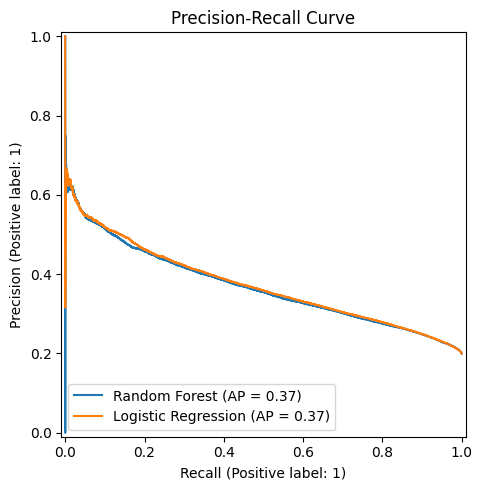


Note: Under class imbalance, the Precision-Recall curve is more informative than ROC-AUC.
A model with high ROC-AUC can still perform poorly at identifying the minority class (defaults).



In [18]:
#--------------------------------------
# 10. Precision-Recall Curve
#--------------------------------------

# PR curve is more informative than ROC-AUC under class imbalance
fig, ax = plt.subplots(figsize=(8, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=ax, name="Random Forest")
PrecisionRecallDisplay.from_predictions(y_test, y_proba_lr, ax=ax, name="Logistic Regression")
ax.set_title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

print("""
Note: Under class imbalance, the Precision-Recall curve is more informative than ROC-AUC.
A model with high ROC-AUC can still perform poorly at identifying the minority class (defaults).
""")

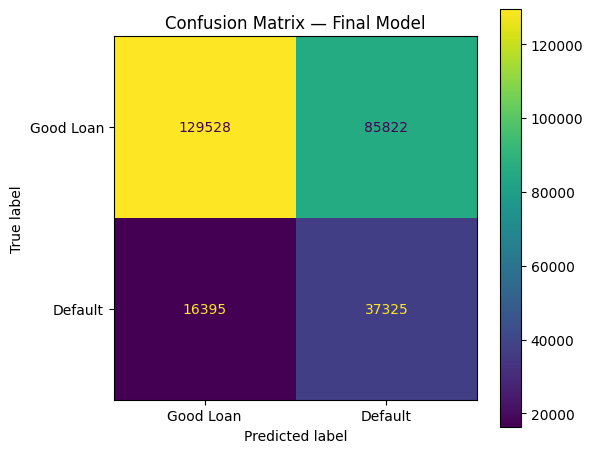

In [19]:
#--------------------------------------
# 11. Confusion Matrix
#--------------------------------------

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Good Loan", "Default"],
    ax=ax
)
plt.title("Confusion Matrix — Final Model")
plt.tight_layout()
plt.show()

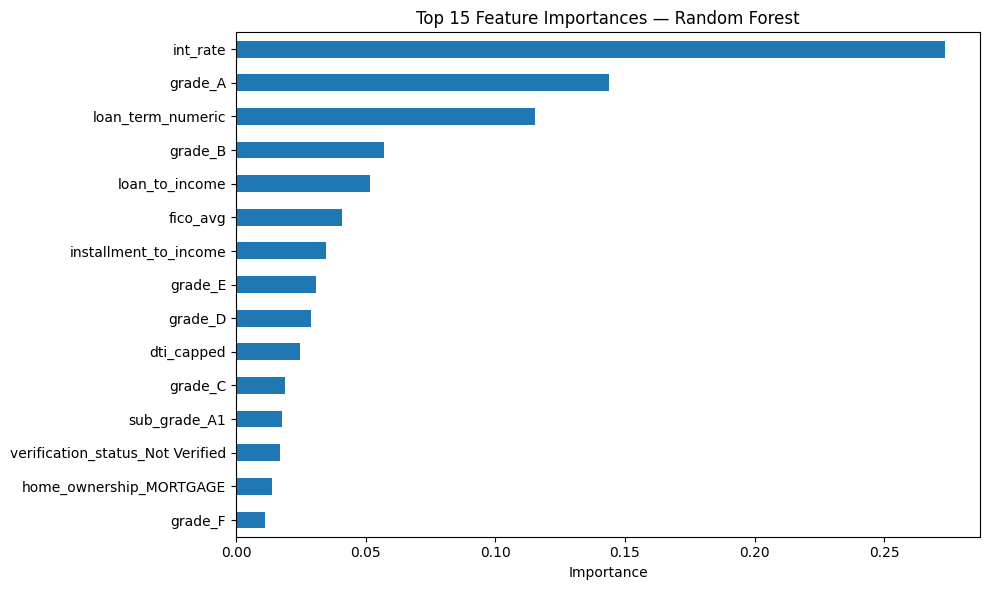

Top 10 features driving default predictions:
int_rate                 0.2732
grade_A                  0.1438
loan_term_numeric        0.1155
grade_B                  0.0571
loan_to_income           0.0517
fico_avg                 0.0407
installment_to_income    0.0348
grade_E                  0.0307
grade_D                  0.0289
dti_capped               0.0247
dtype: float64


In [20]:
#--------------------------------------
# 12. Feature Importance Analysis
#--------------------------------------

# Extract feature names from the fitted preprocessor
ohe_feature_names = (
    final_model["preprocessing"]
    .named_transformers_["cat"]["encoder"]
    .get_feature_names_out(cat_cols)
    .tolist()
)
all_feature_names = num_cols + ohe_feature_names

importances = final_model["classifier"].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind="barh")
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 features driving default predictions:")
print(feat_imp.head(10).round(4))

In [21]:
#--------------------------------------
# 13. Compare with Pure Borrower Model
#--------------------------------------

X_pure = df[PURE_FEATURES].copy()
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pure, y, test_size=0.2, stratify=y, random_state=42
)

num_cols_p = X_train_p.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols_p = X_train_p.select_dtypes(include=["object"]).columns.tolist()

preprocessor_p = ColumnTransformer([
    ("num", numeric_pipeline, num_cols_p),
    ("cat", categorical_pipeline, cat_cols_p)
])

pure_model = Pipeline([
    ("preprocessing", preprocessor_p),
    ("classifier", RandomForestClassifier(
        n_estimators=50, max_depth=6,
        class_weight="balanced",
        random_state=42, n_jobs=1
    ))
])

pure_model.fit(X_train_p, y_train_p)
y_proba_pure = pure_model.predict_proba(X_test_p)[:, 1]

auc_business = roc_auc_score(y_test, y_proba)
auc_pure = roc_auc_score(y_test_p, y_proba_pure)

print("=== Model Comparison ===")
print(f"Business Model (with grade/int_rate) ROC-AUC : {auc_business:.4f}")
print(f"Pure Borrower Model (without grade/int_rate) ROC-AUC: {auc_pure:.4f}")
print()
print("The gap between these two scores shows how much predictive power",
      "comes from institution-assigned features vs raw borrower attributes.")

=== Model Comparison ===
Business Model (with grade/int_rate) ROC-AUC : 0.7058
Pure Borrower Model (without grade/int_rate) ROC-AUC: 0.6825

The gap between these two scores shows how much predictive power comes from institution-assigned features vs raw borrower attributes.


In [22]:
#--------------------------------------
# 14. Save Models and Expected Features
#--------------------------------------

os.makedirs("models", exist_ok=True)

joblib.dump(final_model, "models/credit_risk_model_business.joblib")
joblib.dump(pure_model, "models/credit_risk_model_pure.joblib")
joblib.dump(FULL_FEATURES, "models/expected_features_full.joblib")
joblib.dump(PURE_FEATURES, "models/expected_features_pure.joblib")

print("Models saved:")
print("  models/credit_risk_model_business.joblib")
print("  models/credit_risk_model_pure.joblib")

Models saved:
  models/credit_risk_model_business.joblib
  models/credit_risk_model_pure.joblib
